# Task 4: Time Series Analysis 

## Importing libraries, loading, inspecting and cleaning dataset

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(r"E:\Codveda projects\datasets\2) Stock Prices Data Set.csv")

In [17]:
# head 5
df.head(5)

,symbol,date,open,high,low,close,volume
0,AAL,2014-01-02,25.0700,25.8200,25.0600,25.3600,8998943
1,AAPL,2014-01-02,79.3828,79.5756,78.8601,79.0185,58791957
2,AAP,2014-01-02,110.3600,111.8800,109.2900,109.7400,542711
3,ABBV,2014-01-02,52.1200,52.3300,51.5200,51.9800,4569061
4,ABC,2014-01-02,70.1100,70.2300,69.4800,69.8900,1148391


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 497472 entries, 0 to 497471
Data columns (total 7 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   symbol  497472 non-null  object 
 1   date    497472 non-null  object 
 2   open    497461 non-null  float64
 3   high    497464 non-null  float64
 4   low     497464 non-null  float64
 5   close   497472 non-null  float64
 6   volume  497472 non-null  int64  
dtypes: float64(4), int64(1), object(2)
memory usage: 26.6+ MB


Cleaning nulls.

In [19]:
df.isna().sum()

symbol     0
date       0
open      11
high       8
low        8
close      0
volume     0
dtype: int64

In [20]:
df.dropna(inplace=True)

In [21]:
df.isna().sum()

symbol    0
date      0
open      0
high      0
low       0
close     0
volume    0
dtype: int64

Cleaning date column

In [22]:
# Changing to date datatype
df["date"] = pd.to_datetime(df["date"])

In [23]:
display(df.sample(5))

,symbol,date,open,high,low,close,volume
270618,GOOGL,2016-03-15,746.02,753.01,742.84,750.57,1491578
412573,CRM,2017-05-02,86.79,87.20,86.11,87.09,3503224
260283,LOW,2016-02-12,64.02,64.93,63.41,64.87,4259956
98501,AET,2014-10-22,78.82,79.21,77.70,78.09,2457915
340365,MYL,2016-10-03,38.10,38.22,37.41,38.20,7093747


In [24]:
# Sort the date column
df = df.sort_values(by="date")

In [25]:
display(df.head(5))

,symbol,date,open,high,low,close,volume
0,AAL,2014-01-02,25.07,25.82,25.060,25.36,8998943
330,NVDA,2014-01-02,15.92,15.98,15.720,15.86,6502296
329,NUE,2014-01-02,53.29,53.38,52.510,52.73,1611326
328,NTRS,2014-01-02,61.76,61.95,60.665,60.89,1011050
327,NTAP,2014-01-02,41.01,41.01,40.415,40.42,2427140


In [26]:
# Set date as index

df = df.set_index("date")

In [27]:
display(df.tail(5))

,symbol,open,high,low,close,volume
date,,,,,,
2017-12-29,EMR,70.04,70.21,69.69,69.69,1848874
2017-12-29,EMN,93.71,93.76,92.55,92.64,632351
2017-12-29,EL,127.80,128.13,127.20,127.24,805149
2017-12-29,EVHC,34.70,35.09,34.53,34.56,1471045
2017-12-29,ZTS,72.55,72.76,72.04,72.04,1704122


Close Prices Over Time

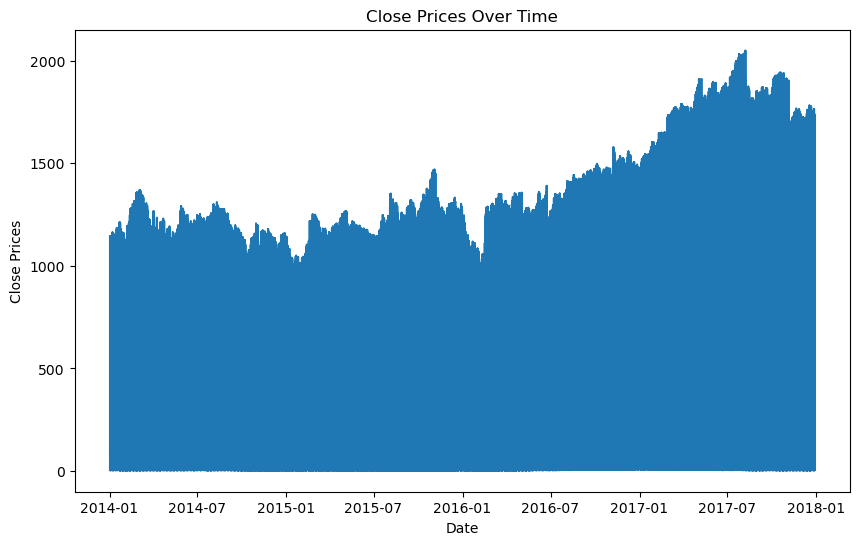

In [41]:
plt.figure(figsize=(10,6))

plt.plot(df["close"])
plt.xlabel("Date")
plt.ylabel("Close Prices")
plt.title("Close Prices Over Time")

plt.show()

Time Series Decomposition

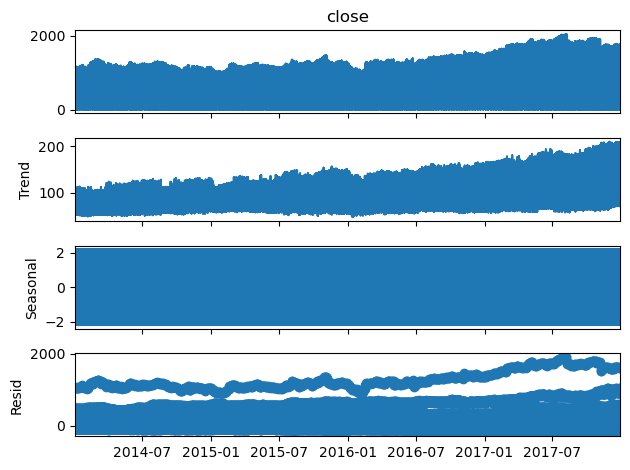

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose # imported decompose function

result = seasonal_decompose(
    df['close'],
    model='additive',
    period=30 # daily time series
)

result.plot()
plt.show()

Moving Average (Close Prices)

In [47]:
# 7 days moving average
df['MA7'] = df['close'].rolling(window=7).mean()

In [48]:
# 30 days moving average
df['MA30'] = df['close'].rolling(window=30).mean()

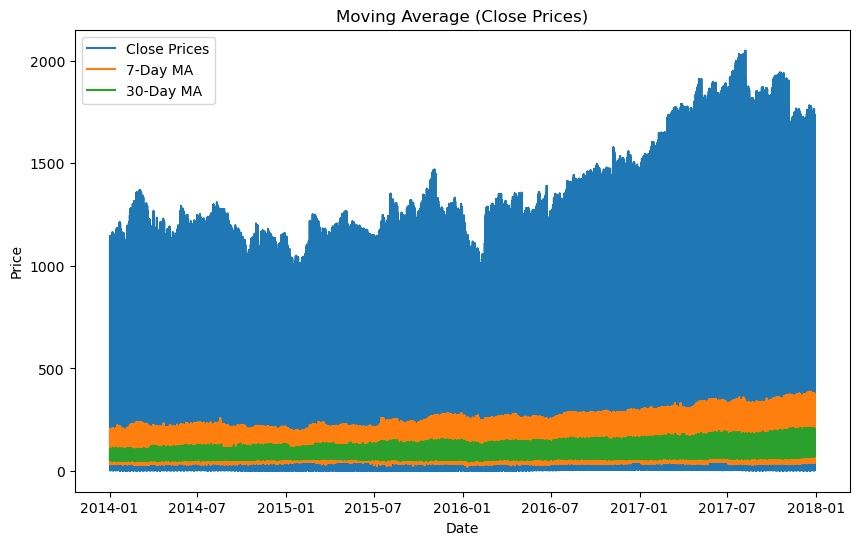

In [54]:
plt.figure(figsize=(10,6))

plt.plot(df['close'], label='Close Prices')
plt.plot(df['MA7'], label='7-Day MA')
plt.plot(df['MA30'], label='30-Day MA')

plt.legend()

plt.title("Moving Average (Close Prices)")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()